## 

# Gradient Descent from Scratch

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Create the regression dataset
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

In [4]:
# 2. Define our documented 1D Gradient Descent Regressor
class GDRegressor1D:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.m = 0.0  # Initial blind guess for slope
        self.b = 0.0  # Initial blind guess for intercept
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self, X, y):
        # Flatten arrays to prevent NumPy broadcasting shape bugs
        X = X.ravel()
        y = y.ravel()
        
        
        for i in range(self.epochs):
            # Calculate current predictions (y_hat = mx + b)
            y_hat = self.m * X + self.b
            
            # Compute average gradients using np.mean()
            intercept_der = -2 * np.mean(y - y_hat)
            slope_der = -2 * np.mean((y - y_hat) * X)
            
            # Simultaneously update the parameters
            self.b = self.b - (self.lr * intercept_der)
            self.m = self.m - (self.lr * slope_der)
            
    
    def predict(self, X):
        return self.m * X + self.b

# 3. Instantiate and Train the Model
# A slightly higher learning rate like 0.05 helps it converge beautifully within 100 epochs
model = GDRegressor1D(learning_rate=0.05, epochs=100)
model.fit(X, y)

# 4. Predict values for the line plotting
X_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(X_line)


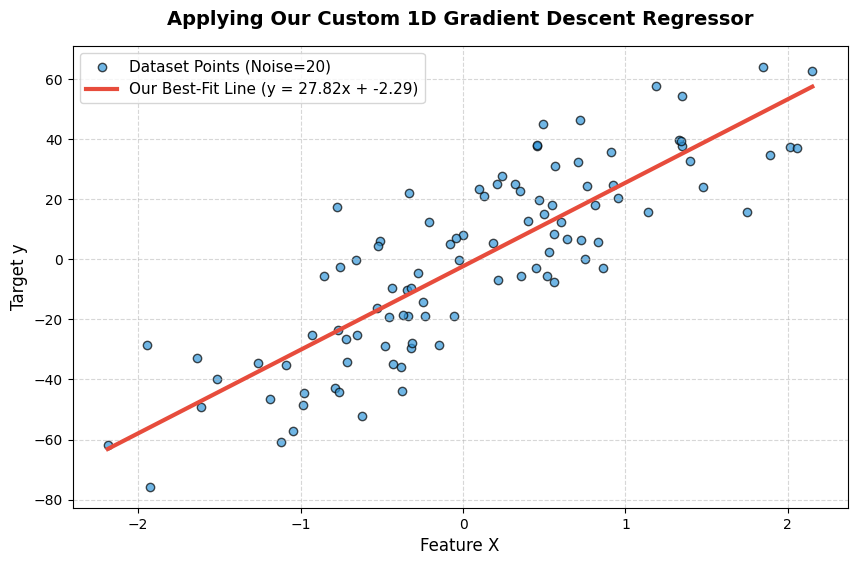

In [5]:
# 5. Plot the result for your blog post
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='#3498db', alpha=0.7, edgecolors='k', label='Dataset Points (Noise=20)')
plt.plot(X_line, y_line, color='#e74c3c', linewidth=3, label=f'Our Best-Fit Line (y = {model.m:.2f}x + {model.b:.2f})')

# Add professional blog styling
plt.title('Applying Our Custom 1D Gradient Descent Regressor', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feature X', fontsize=12)
plt.ylabel('Target y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

In [6]:
# For multiple linear reggresion apply gradient decent
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [7]:
X, y = load_diabetes(return_X_y=True)

In [8]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
lr.coef_

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [12]:
lr.intercept_

151.34560453985995

In [13]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot(X_train.T, (y_train - y_hat)) / X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [46]:
gdr = GDRegressor(epochs=100,learning_rate=0.5)

In [47]:
gdr.fit(X_train, y_train)

152.7759908965099 [ 44.5561274  -13.3979599  169.76475925 124.51915735  34.84198841
  20.29845847 -98.02081711 101.35823541 147.90082409  97.74401393]


In [48]:
y_pred = gdr.predict(X_test)

In [49]:
r2_score(y_test,y_pred)

0.3394929438890564